# GWOSC #6 2023 Challenge Problems

#### Initialization

In [1]:
! pip install -q lalsuite
! pip install -q gwpy
! pip install -q pycbc
# -- Click "restart runtime" in the runtime menu

# -- download data
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge1.gwf
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge2.gwf
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge4.gwf
from gwpy.timeseries import TimeSeries
from pycbc import frame
from pycbc.waveform import get_td_waveform, fd_approximants, td_approximants
import pylab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 31.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to buil

/usr/local/lib/python3.10/dist-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


#### Question 1

Sampling rate: 0.000244140625 s


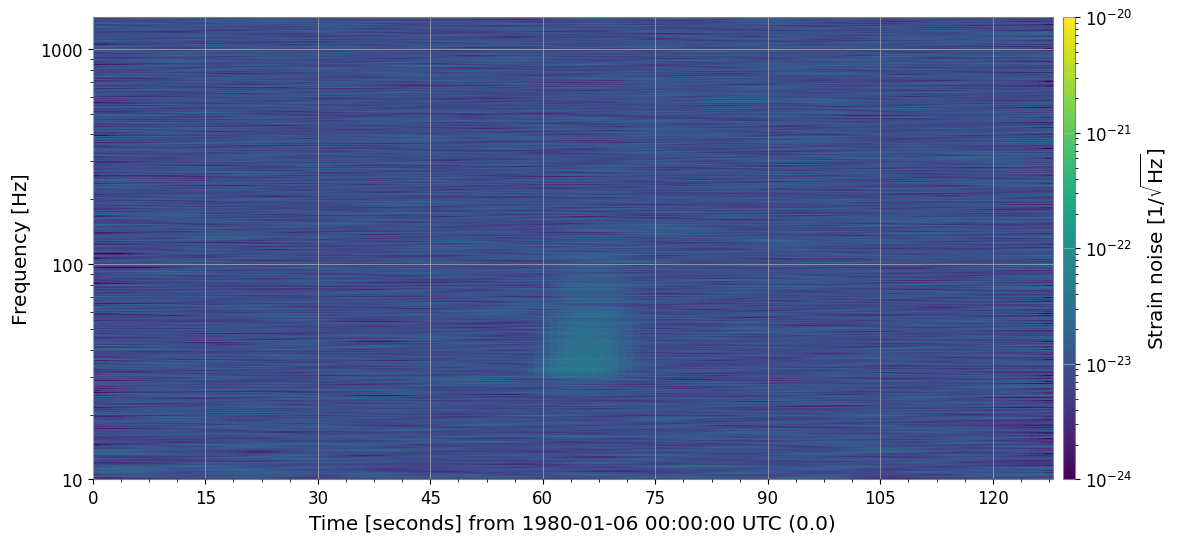

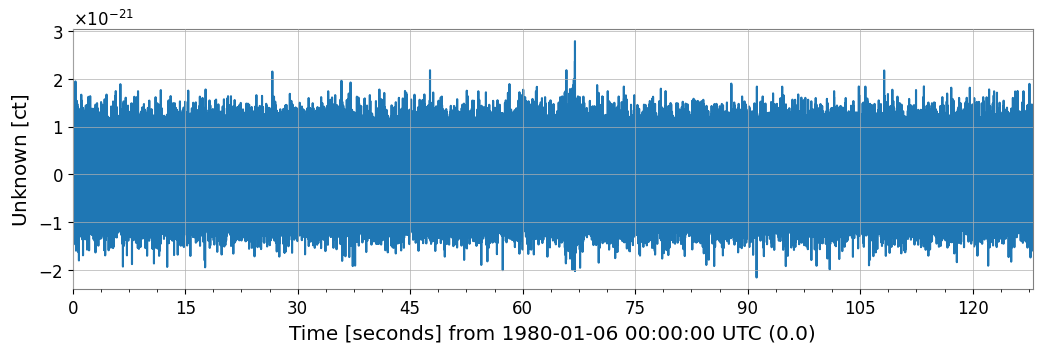

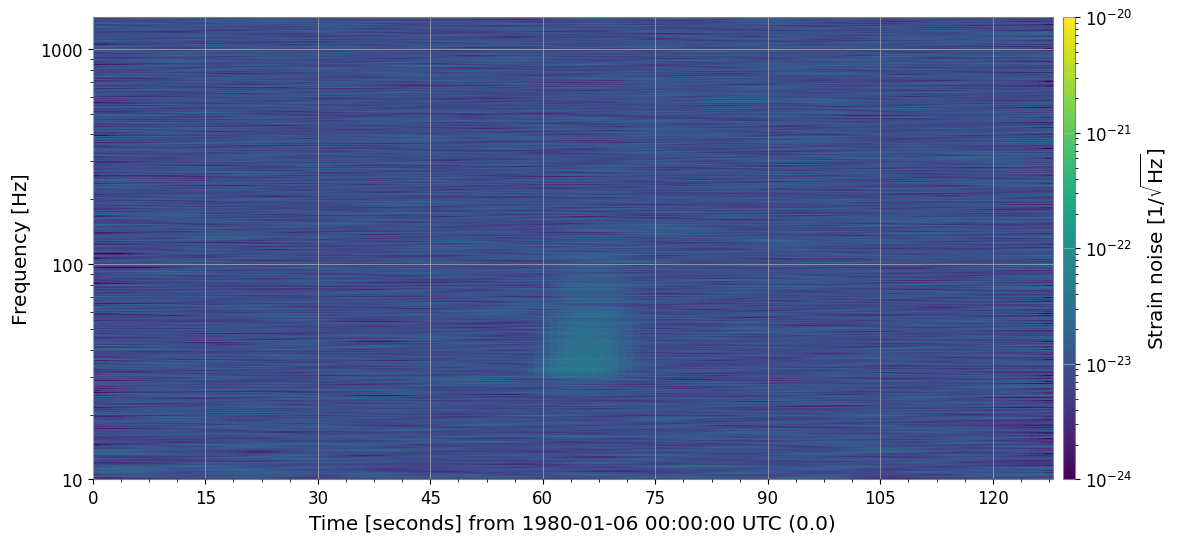

In [2]:
#Question1:
gwpy_strain = TimeSeries.read('challenge1.gwf', channel="H1:CHALLENGE1")
pycbc_strain = frame.read_frame('challenge1.gwf', 'H1:CHALLENGE1')

#a-
print('Sampling rate:',gwpy_strain.dt)

#b-
gwpy_strain.plot()
#c-
specgram = gwpy_strain.spectrogram2(fftlength=10, overlap=9, window='hann') ** (1/2.)
plot = specgram.plot()
ax = plot.gca()
ax.set_yscale('log')
ax.set_ylim(10, 1400)
ax.colorbar(
    clim=(1e-24, 1e-20),
    norm="log",
    label=r"Strain noise [$1/\sqrt{\mathrm{Hz}}$]",
)
plot

#### Question 2

In [3]:
# Importing libraries and modules
import pycbc.noise
import pycbc.psd
import pylab
from pycbc.catalog import Merger
from pycbc.filter import resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.filter import matched_filter
import numpy as np


In [4]:
#Question 2:
gwpy_strain = TimeSeries.read('challenge2.gwf', channel="H1:CHALLENGE2")
pycbc_strain = frame.read_frame('challenge2.gwf', 'H1:CHALLENGE2')

In [5]:
#The Nyquist frequency is the highest frequency that equipment of a given
#sample rate can reliably measure, one-half the given sample rate.
data_length = 4096
del_t = gwpy_strain.dt.value
del_f = 1 / data_length
sampling_rate = 1. / del_t
f_nyquist = 0.5 * sampling_rate
f_nyquist
# print(gwpy_strain.info)
# print(dir(gwpy_strain.info))

2048.0

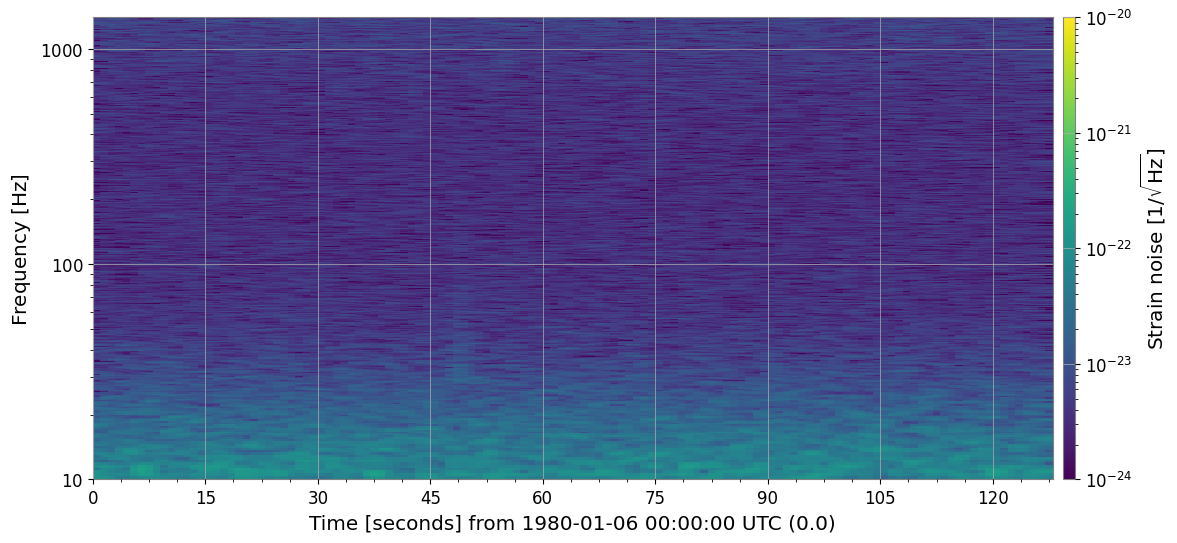

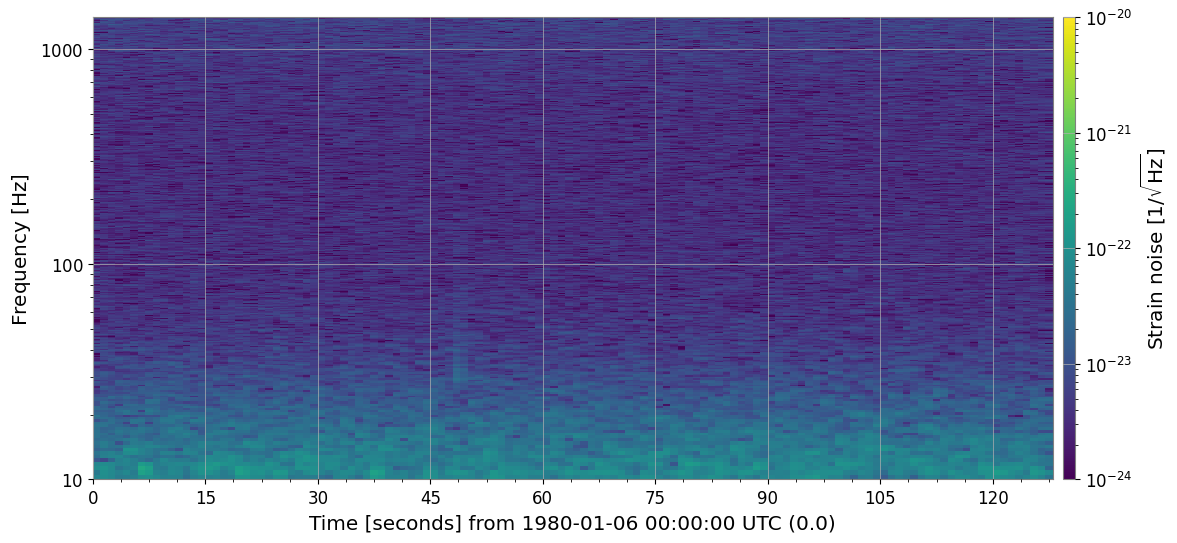

In [6]:
#Part 1: What is the approximative time of the merger? (Hint: a plot of the q-transform could help)
#plot 1
specgram = gwpy_strain.spectrogram2(fftlength=3, overlap=2, window='hann') ** (1/2.)
plot = specgram.plot()
ax = plot.gca()
ax.set_yscale('log')
ax.set_ylim(10, 1400)
ax.colorbar(clim=(1e-24, 1e-20),norm="log",label=r"Strain noise [$1/\sqrt{\mathrm{Hz}}$]")

#plot 2
specgram = gwpy_strain.spectrogram2(fftlength=2, overlap=1, window='hann') ** (1/2.)
plot = specgram.plot()
ax = plot.gca()
ax.set_yscale('log')
ax.set_ylim(10, 1400)
ax.colorbar(clim=(1e-24, 1e-20),norm="log",label=r"Strain noise [$1/\sqrt{\mathrm{Hz}}$]")


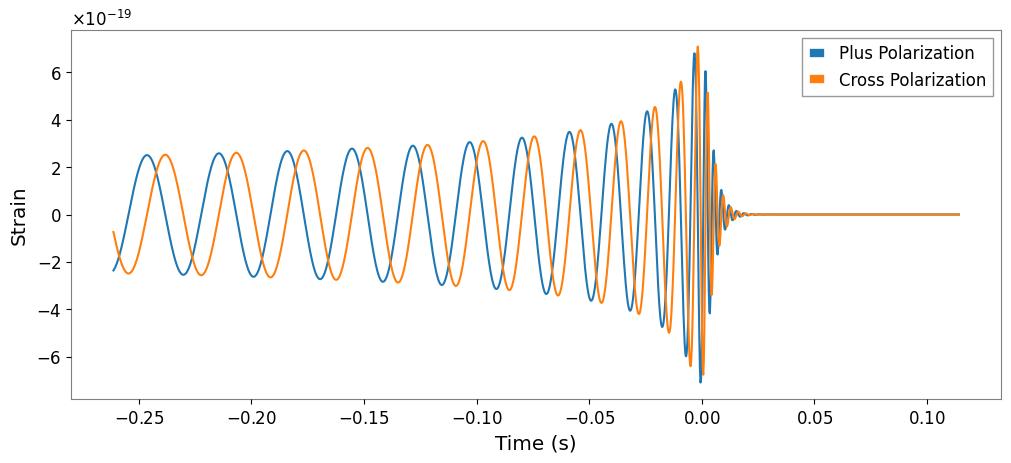

In [7]:
#Part 2: Generate a time-domain template waveform using approximate "SEOBNRv4_opt". with the same parameters as above. Plot this waveform.
aprx = "SEOBNRv4_opt"
hp, hc = get_td_waveform(approximant=aprx,
                         mass1=30,
                         mass2=30,
                         delta_t=del_t,
                         f_lower=30)
pylab.figure(figsize=pylab.figaspect(0.4))
pylab.plot(hp.sample_times, hp, label='Plus Polarization')
pylab.plot(hp.sample_times, hc, label='Cross Polarization')
pylab.xlabel('Time (s)')
pylab.ylabel('Strain')
pylab.legend()
pylab.grid()
pylab.show()

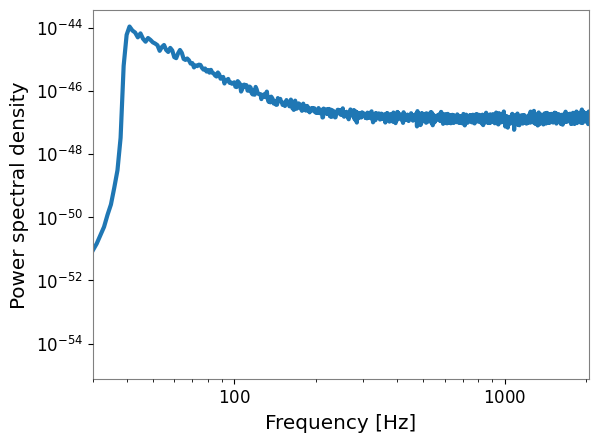

In [8]:
#Part 3: Calculate a PSD of the data, and plot this on a log-log scale. Use axes ranging from 20 Hz up to the Nyquist frequency.
#Power spectral density of t:
psd_data = pycbc_strain.psd(4)
pylab.loglog(psd_data,linewidth=3)
pylab.xlim(30,f_nyquist)
pylab.xlabel('Frequency [Hz]')
pylab.ylabel('Power spectral density')
pylab.grid()
pylab.show()
flen = int(sampling_rate / (2 * del_f)) + 1

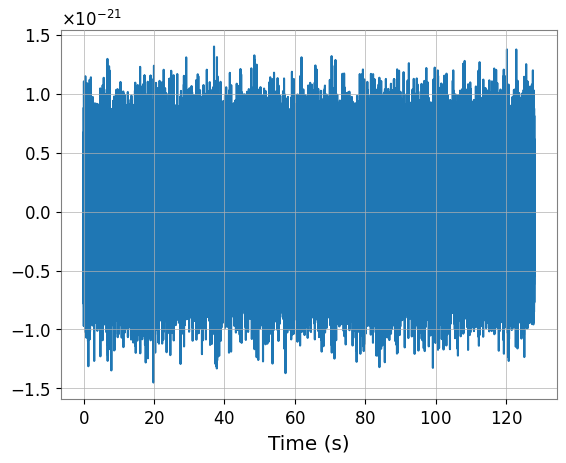

In [9]:
# Time series of the strain data:

pylab.plot(pycbc_strain.sample_times, pycbc_strain)
pylab.xlabel('Time (s)')
pylab.show()

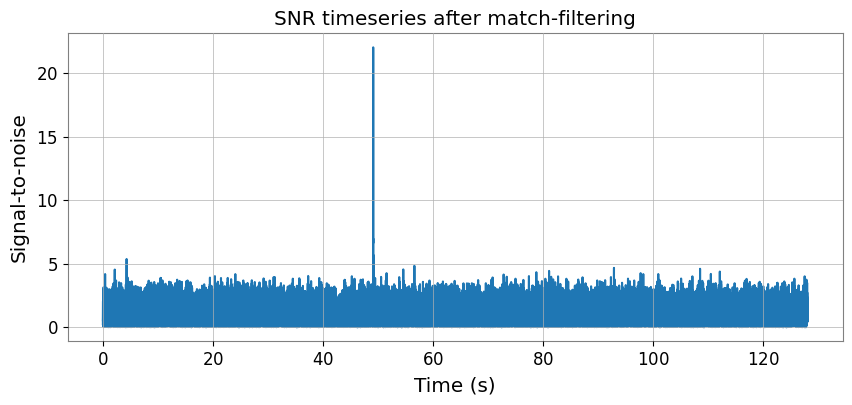

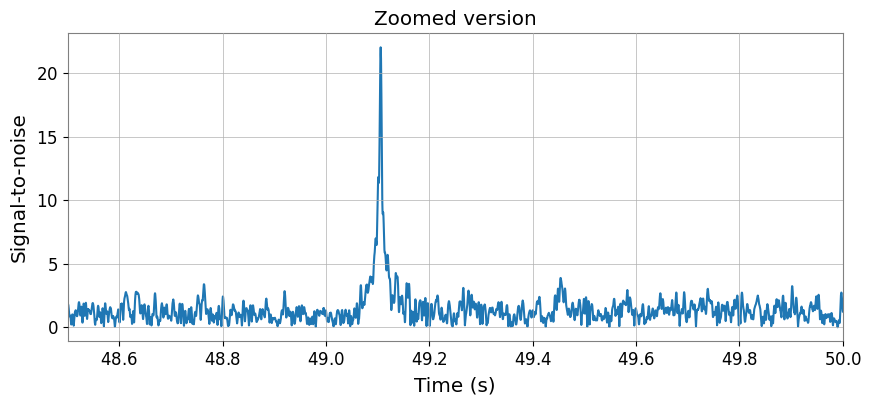


 We found a signal at 49.105712890625s with SNR 22.052916545095535


In [10]:
#Part 4: Use the template waveform and PSD to calculate the SNR time series. Plot the SNR time-series.

psd = pycbc_strain.psd(4)
psd = interpolate(psd, pycbc_strain.delta_f)
psd = inverse_spectrum_truncation(psd, int(4 * pycbc_strain.sample_rate), low_frequency_cutoff=15)

hp.resize(len(pycbc_strain)) # Resize the strain data

snr = matched_filter(hp, pycbc_strain, psd=psd, low_frequency_cutoff=20)

pylab.figure(figsize=[10, 4])
pylab.plot(snr.sample_times, abs(snr))
pylab.title('SNR timeseries after match-filtering')
pylab.ylabel('Signal-to-noise')
pylab.xlabel('Time (s)')
pylab.show()

pylab.figure(figsize=[10, 4])
pylab.plot(snr.sample_times, abs(snr))
pylab.title('Zoomed version')
pylab.ylabel('Signal-to-noise')
pylab.xlabel('Time (s)')
pylab.xlim(48.5,50)
pylab.show()

peak = abs(snr).numpy().argmax()
snrp = snr[peak]
time = snr.sample_times[peak]

#Part 5: What is the matched filter SNR of the signal?
print("\n We found a signal at {}s with SNR {}".format(time, abs(snrp)))

#### Question 3

In [11]:
gwpy_strain = TimeSeries.read('challenge3.gwf', channel="H1:CHALLENGE3")
pycbc_strain = frame.read_frame('challenge3.gwf', 'H1:CHALLENGE3')

In [12]:
#The Nyquist frequency is the highest frequency that equipment of a given
#sample rate can reliably measure, one-half the given sample rate.
data_length = 4096
del_t = gwpy_strain.dt.value
del_f = 1 / data_length
sampling_rate = 1. / del_t
f_nyquist = 0.5 * sampling_rate
f_nyquist
# print(gwpy_strain.info)
# print(dir(gwpy_strain.info))

2048.0

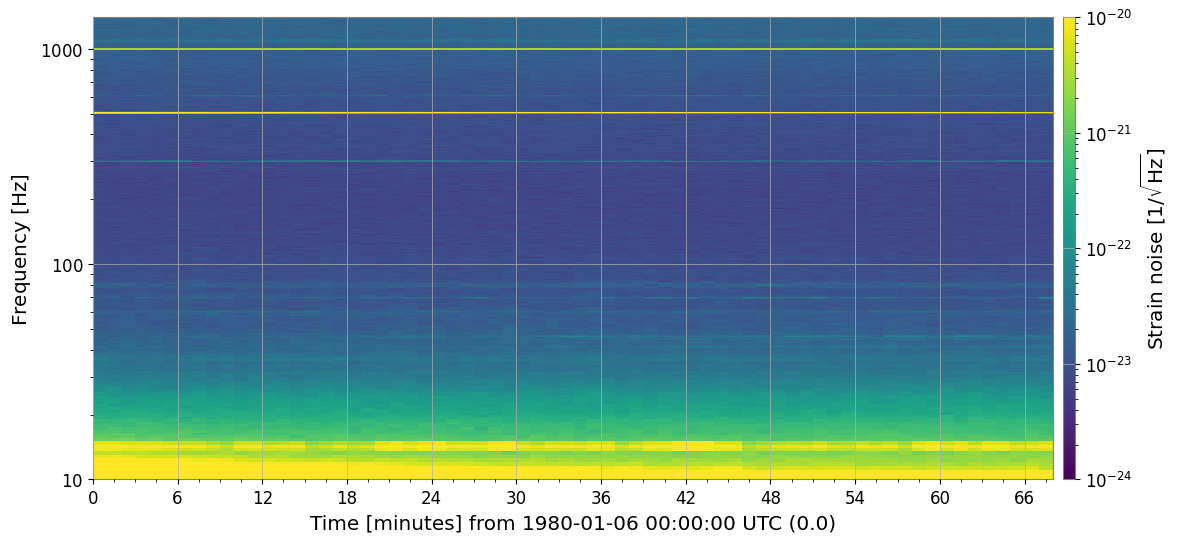

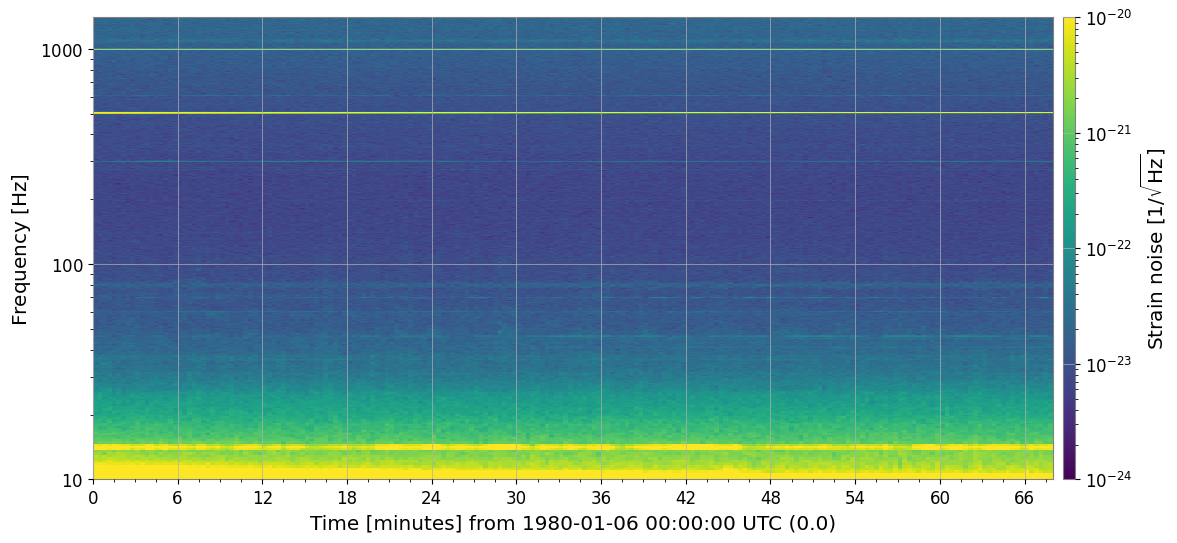

In [13]:
#Part 1: What is the approximative time of the merger? (Hint: a plot of the q-transform could help)
#plot 1
specgram = gwpy_strain.spectrogram(stride=60, fftlength=2, overlap=1, window='hann') ** (1/2.)
plot = specgram.plot()
ax = plot.gca()
ax.set_yscale('log')
ax.set_ylim(10, 1400)
ax.colorbar(clim=(1e-24, 1e-20),norm="log",label=r"Strain noise [$1/\sqrt{\mathrm{Hz}}$]")

#plot 2
specgram = gwpy_strain.spectrogram(stride=20,fftlength=3, overlap=2, window='hann') ** (1/2.)
plot = specgram.plot()
ax = plot.gca()
ax.set_yscale('log')
ax.set_ylim(10, 1400)
ax.colorbar(clim=(1e-24, 1e-20),norm="log",label=r"Strain noise [$1/\sqrt{\mathrm{Hz}}$]")


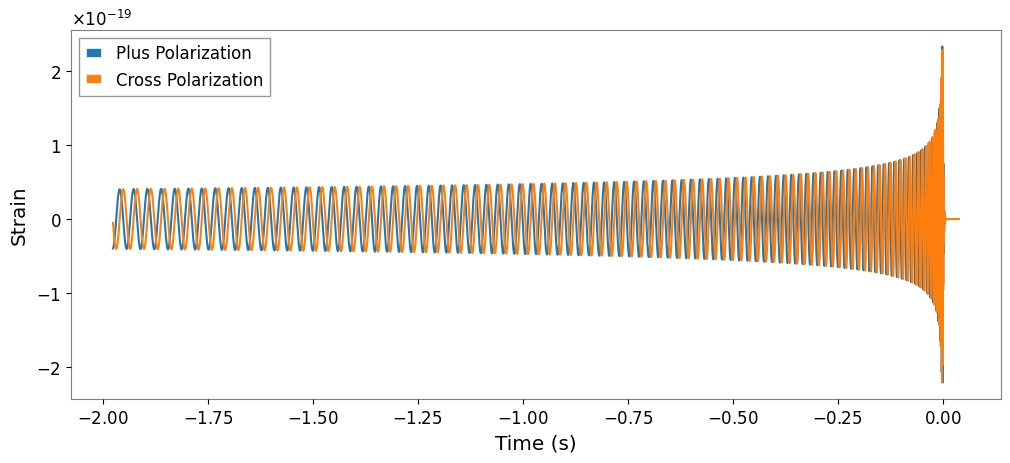

In [14]:
#Part 2: Generate a time-domain template waveform using approximate "SEOBNRv4_opt". with the same parameters as above. Plot this waveform.
aprx = "SEOBNRv4_opt"
hp, hc = get_td_waveform(approximant=aprx,
                         mass1=10,
                         mass2=10,
                         delta_t=del_t,
                         f_lower=30)
pylab.figure(figsize=pylab.figaspect(0.4))
pylab.plot(hp.sample_times, hp, label='Plus Polarization')
pylab.plot(hp.sample_times, hc, label='Cross Polarization')
pylab.xlabel('Time (s)')
pylab.ylabel('Strain')
pylab.legend()
pylab.grid()
pylab.show()

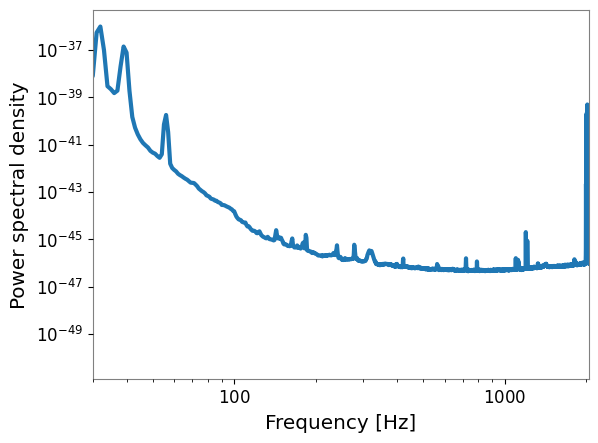

In [15]:
#Part 3: Calculate a PSD of the data, and plot this on a log-log scale. Use axes ranging from 20 Hz up to the Nyquist frequency.
#Power spectral density of t:
psd_data = pycbc_strain.psd(4)
pylab.loglog(psd_data,linewidth=3)
pylab.xlim(30,f_nyquist)
pylab.xlabel('Frequency [Hz]')
pylab.ylabel('Power spectral density')
pylab.grid()
pylab.show()
flen = int(sampling_rate / (2 * del_f)) + 1

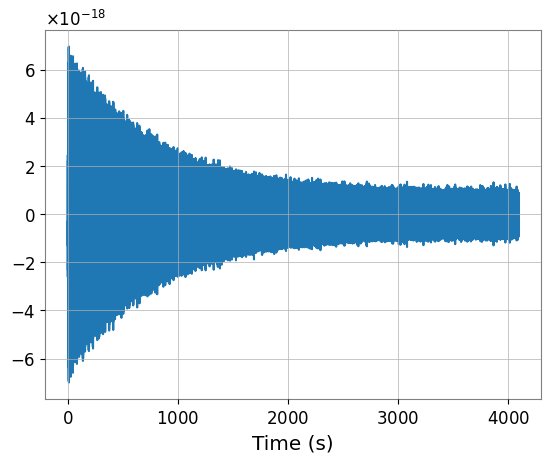

In [16]:
# Time series of the strain data:

pylab.plot(pycbc_strain.sample_times, pycbc_strain)
pylab.xlabel('Time (s)')
pylab.show()

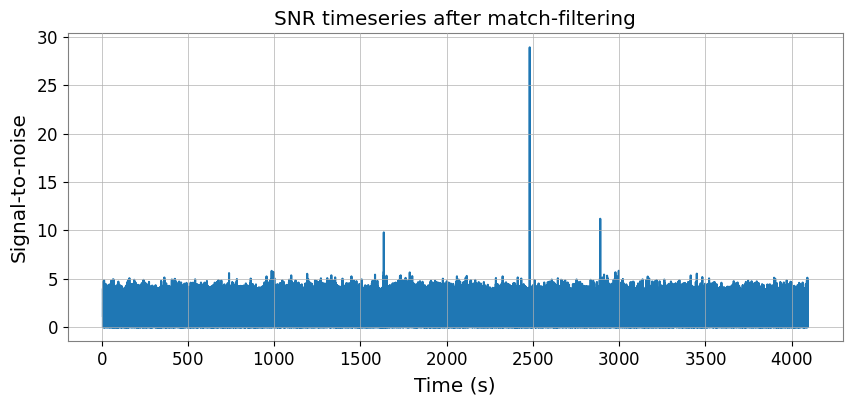


 We found a signal at 2481.991943359375s with SNR 28.895263408766724


In [17]:
#Part 4: Use the template waveform and PSD to calculate the SNR time series. Plot the SNR time-series.

psd = pycbc_strain.psd(4)
psd = interpolate(psd, pycbc_strain.delta_f)
psd = inverse_spectrum_truncation(psd, int(4 * pycbc_strain.sample_rate), low_frequency_cutoff=15)

hp.resize(len(pycbc_strain)) # Resize the strain data

snr = matched_filter(hp, pycbc_strain, psd=psd, low_frequency_cutoff=20)
snr = snr.crop(4 + 4, 4)

pylab.figure(figsize=[10, 4])
pylab.plot(snr.sample_times, abs(snr))
pylab.title('SNR timeseries after match-filtering')
pylab.ylabel('Signal-to-noise')
pylab.xlabel('Time (s)')
pylab.show()



peak = abs(snr).numpy().argmax()
snrp = snr[peak]
time = snr.sample_times[peak]

#Part 5: What is the matched filter SNR of the signal?
print("\n We found a signal at {}s with SNR {}".format(time, abs(snrp)))

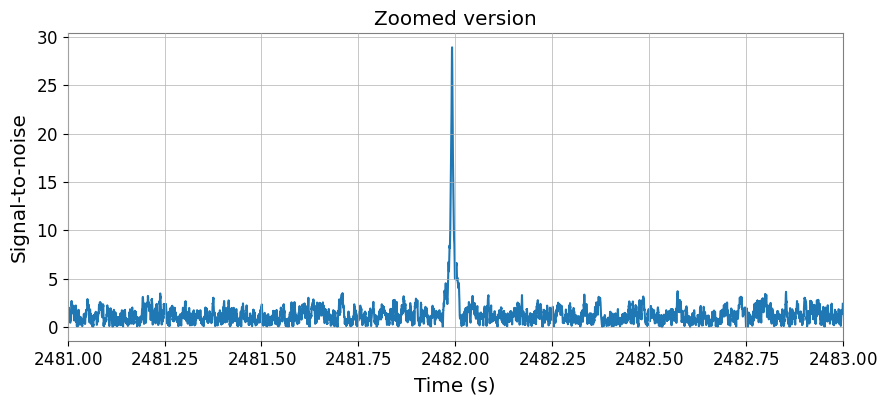

In [18]:
pylab.figure(figsize=[10, 4])
pylab.plot(snr.sample_times, abs(snr))
pylab.title('Zoomed version')
pylab.ylabel('Signal-to-noise')
pylab.xlabel('Time (s)')
pylab.xlim(2481,2483)
pylab.show()

#### Question 4

In [19]:
gwpy_strain_h1 = TimeSeries.read('challenge3.gwf', channel="H1:CHALLENGE3")
pycbc_strain_h1 = frame.read_frame('challenge3.gwf', 'H1:CHALLENGE3')

gwpy_strain_l1 = TimeSeries.read('challenge3.gwf', channel="L1:CHALLENGE3")
pycbc_strain_l1 = frame.read_frame('challenge3.gwf', 'L1:CHALLENGE3')

In [20]:
#The Nyquist frequency is the highest frequency that equipment of a given
#sample rate can reliably measure, one-half the given sample rate.
data_length = 4096
del_t = gwpy_strain_l1.dt.value
del_f = 1 / data_length
sampling_rate = 1. / del_t
f_nyquist = 0.5 * sampling_rate
f_nyquist
# print(gwpy_strain.info)
# print(dir(gwpy_strain.info))

2048.0

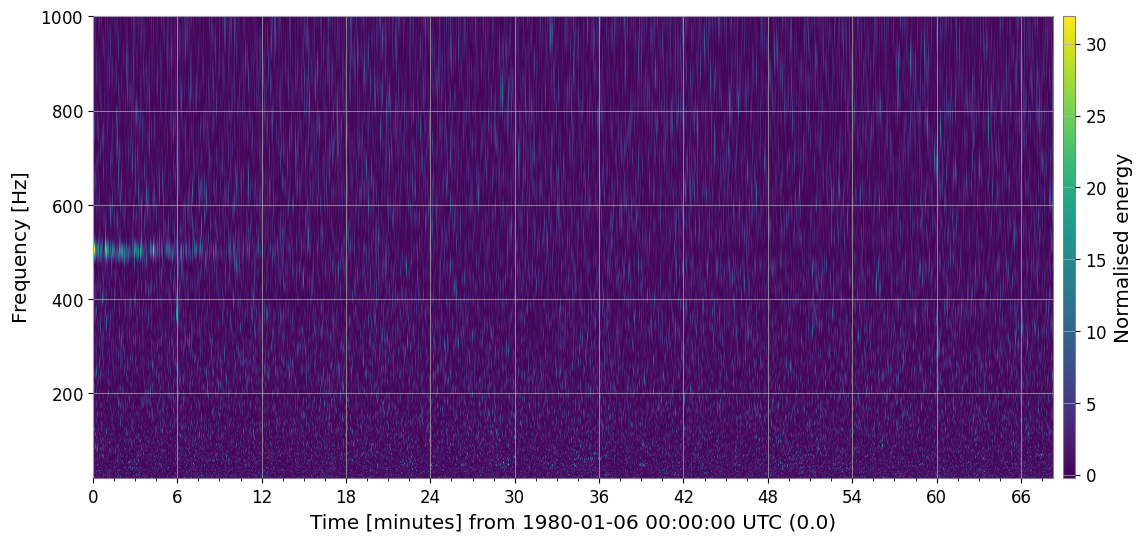

In [21]:
gwpy_strain_h1_q = gwpy_strain_h1.q_transform(frange=(20, 1000),qrange=(40,50))
plot = gwpy_strain_h1_q.plot()
ax = plot.gca()
ax.colorbar(label="Normalised energy")

In [22]:
mass=np.arange(10,51)
ts = pycbc_strain_h1
data = resample_to_delta_t(ts, 1.0/2048)
conditioned = data
snr_max_all=[]
window = 500
for m in mass:
  hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
  mass1=m,
  mass2=m,
  delta_t=conditioned.delta_t,
  f_lower=20)
  hp.resize(len(conditioned))
  template = hp.cyclic_time_shift(hp.start_time)
  snr = matched_filter(template, conditioned, psd=psd, low_frequency_cutoff=20)
  snr = snr.crop(4 + 4, 4)

  snr_max_given_m = []
  t=0
  while t<len(snr):
    if abs(snr[t])>8:
      snr_max_given_m.append([m,snr.sample_times[t],abs(max(snr[t:t+window]))])
      t+=window
    t+=1
  snr_max_all.append(snr_max_given_m)

In [23]:
snr_max_all

[[[10, 1638.15966796875, 8.948013569647449],
  [10, 2483.9609375, 28.87509289739556],
  [10, 2892.71240234375, 9.946195962829192]],
 [[11, 1638.15869140625, 9.906331190815308],
  [11, 2483.94091796875, 10.435470700873287],
  [11, 2892.7119140625, 10.746126331694665]],
 [[12, 1638.158203125, 10.690558595179306],
  [12, 2483.9599609375, 8.42837300130254],
  [12, 2892.71044921875, 10.96018146704538]],
 [[13, 1638.15771484375, 13.938605909611887],
  [13, 2483.9599609375, 8.302682363202278],
  [13, 2892.71044921875, 13.966852849339944]],
 [[14, 1638.15673828125, 12.249437558007383],
  [14, 2892.7099609375, 14.003140845300805]],
 [[15, 1638.15576171875, 18.527966433354646],
  [15, 2892.70947265625, 14.992091172178824]],
 [[16, 1638.1552734375, 26.03730536488134],
  [16, 2892.708984375, 20.468444443131848]],
 [[17, 1638.14892578125, 37.76283018719278],
  [17, 2892.7080078125, 16.669683454073134]],
 [[18, 1638.1259765625, 23.26516986778239],
  [18, 2892.70751953125, 15.66125389412385]],
 [[19,